# VECTRA-X · 01 — Data Audit & EDA

Loads the official `data.csv`, audits schema/missingness, detects the multi-label target, runs the **leakage audit**, and renders the EDA figures.

*Runs top-to-bottom in well under a minute.*

In [1]:
# --- robust project bootstrap: works whether launched from notebooks/ or root ---
import sys, os
from pathlib import Path
p = Path.cwd()
while not (p / 'src').exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p)); os.chdir(p)
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 160)
from IPython.display import Image, display
from src import report_utils as ru
cfg = ru.load_config(); RS = cfg['project']['random_state']
FIG = ru.resolve(cfg['paths']['figures']); TAB = ru.resolve(cfg['paths']['tables'])
print('Project root:', p)


Project root: C:\Users\rapha\Documents\VSCode\Kaggle\FIT\vectra_x_project


In [2]:
from src import data_loader as dl, schema_audit as sa, label_detection as ld, leakage_audit as lk
df = dl.load_raw(cfg)
dic = dl.load_dictionary(cfg)
print('shape:', df.shape, '| duplicates:', int(df.duplicated().sum()))
df.head(3)

02:43:56 | INFO    | src.data_loader | Loaded raw CSV with encoding=utf-8 sep=';' -> 300 rows x 109 cols


02:43:56 | INFO    | src.data_loader | Loaded data dictionary: 64 rows x 4 cols


shape: (300, 109) | duplicates: 0


,Centre de santé,Genre (Gender),Âge (Age),Poids (Weight),Circonference du bras (Mua circumference),"Haute température.(temperature, Hyperpyrexia)",Fièvre depuis 48 heures(Fever 48 hrs),Fièvre au cours des 7 derniers jours (Fever in the last 7 days),Type de fièvre (Type of Fever),Perte de poids (Loss of Weight),Maux de tête (headache),Nausée (Nausea),Vomissement (Vomiting),Douleur articulaire (Joint pain),Gonflement des articulations (Joint Swelling),Douleur musculaire ( Muscle pain),Douleur Thoracique (Chaist pain),Mal de dos / Douleur rachidienne ( Back pain / Rachiodynia),Troubles de la conscience (Consciousness trouble),Perte d'appétit ou Anorexie (Loss of appetite or Anorexia),...,Maladie auto immune,Arthrose,Allergies,Cancer,Asthme (Astma),Carences en leucocytes (Leucopenia),Pneumonie (Pneumonia),Dengue dans le menage (Household Dengue),Dengue (Dengua),Maladies diagnostiquées,Maladies diagnostiquées/Paludisme (Malaria),Maladies diagnostiquées/Dengue,Maladies diagnostiquées/Chikunguya,Maladies diagnostiquées/Fièvre jaune (yellow fever),Maladies diagnostiquées/Fièvre Typhoïde (Thyphoid fever),Maladies diagnostiquées/Zika,Maladies diagnostiquées/Autres maladies diagnostiqué (Others diseases),Maladies diagnostiquées/Option 8,Autres maladies présentées par le patient,_uuid
0,CMA de DO,Femme,18,55,NaN,OUI,OUI,OUI,Récurrente,NON,OUI,OUI,NON,OUI,NON,OUI,NON,NON,NON,OUI,...,NON,NON,NON,NON,NON,NON,NON,NON,NaN,Paludisme (Malaria) Dengue,1,1,0,0,0,0,0,0,NaN,df22d899-23a3-4c49-8059-6208c130f57d
1,CMA de DO,Homme,26,120,NaN,OUI,OUI,OUI,Récurrente,NON,OUI,OUI,OUI,OUI,NON,OUI,NON,NON,NON,NON,...,NON,NON,NON,NON,NON,NON,NON,OUI,OUI,Paludisme (Malaria) Dengue,1,1,0,0,0,0,0,0,NaN,4a7ef2f3-4ff0-4215-8cb5-20ba8c8d4355
2,CMA de DO,Homme,25,63,NaN,OUI,OUI,OUI,Récurrente,NON,OUI,NON,OUI,OUI,NON,OUI,NON,NON,NON,OUI,...,NON,NON,NON,NON,NON,NON,NON,NON,NON,Paludisme (Malaria) Fièvre Typhoïde (Thyphoid ...,1,0,0,0,1,0,0,0,NaN,104f6bc8-f39a-482b-b680-7ac1f8cccc86


## Schema & missingness

In [3]:
audit = sa.audit_schema(df, dic, cfg)
print(audit['data_dictionary']['role'].value_counts())
audit['missingness'].head(12)

02:43:57 | INFO    | src.schema_audit | Schema audit: 109 cols -> 14 numeric, 81 binary, 1 categorical, 11 constant, 1 high-cardinality; 0 duplicate rows.


role
binary                   81
numeric                  14
constant                 11
categorical               1
text_high_cardinality     1
id                        1
Name: count, dtype: int64


,column,n_missing,missing_pct,role
0,Circonference du bras (Mua circumference),275,91.67,numeric
1,Temps de remplissage capillaire (médiane secs ...,209,69.67,numeric
2,Autres maladies présentées par le patient,206,68.67,text_high_cardinality
3,Pression artérielle (moyenne mmHg ± SD). / Art...,171,57.00,numeric
4,Lymphocytes,153,51.00,numeric
5,Hematocrite (Hematrocrit),105,35.00,numeric
6,Poids (Weight),104,34.67,numeric
7,Fréquence respiratoire (médiane IQR) / Respira...,88,29.33,numeric
8,Créatinine élevée / Elevated Creatinine,82,27.33,numeric
9,Neutrophiles / Neutrophils,81,27.00,numeric


## Multi-label target detection
Five active labels; three inactive (zero positives). Binary↔free-text agreement is 100%.

In [4]:
labels = ld.detect_labels(df, cfg)
print('ACTIVE  :', labels['active_labels'])
print('INACTIVE:', labels['inactive_labels'])
print('multi-label patients:', labels['n_multilabel_patients'])
labels['distribution']

02:43:57 | INFO    | src.label_detection | Detected 8 label columns -> 5 ACTIVE ['malaria', 'other_diseases', 'dengue', 'typhoid', 'yellow_fever'], 3 INACTIVE ['chikungunya', 'zika', 'option_8']


ACTIVE  : ['malaria', 'other_diseases', 'dengue', 'typhoid', 'yellow_fever']
INACTIVE: ['chikungunya', 'zika', 'option_8']
multi-label patients: 158


,label,positives,prevalence_pct,status
0,malaria,270,90.00,active
1,other_diseases,99,33.00,active
2,dengue,56,18.67,active
3,typhoid,29,9.67,active
4,yellow_fever,12,4.00,active
5,chikungunya,0,0.00,inactive
6,zika,0,0.00,inactive
7,option_8,0,0.00,inactive


In [5]:
display(labels['cardinality'])
display(labels['top_combinations'].head(10))
labels['cooccurrence']

,n_labels,n_patients,pct
0,0,1,0.33
1,1,141,47.00
2,2,149,49.67
3,3,9,3.00


,combination,n_patients
0,malaria,119
1,malaria+other_diseases,74
2,malaria+dengue,36
3,malaria+typhoid,24
4,other_diseases,14
5,malaria+yellow_fever,8
6,dengue,8
7,malaria+other_diseases+dengue,5
8,other_diseases+dengue,3
9,dengue+yellow_fever,2


,malaria,other_diseases,dengue,typhoid,yellow_fever
malaria,270,82,42,27,9
other_diseases,82,99,8,2,1
dengue,42,8,56,2,2
typhoid,27,2,2,29,1
yellow_fever,9,1,2,1,12


## Leakage & clinical-stage audit
Each feature is screened by name pattern AND statistics, then routed to a stage.

In [6]:
feat_cols = ld.feature_columns(df, labels['label_columns_raw'], cfg)
dcats = dict(zip(audit['data_dictionary']['column'], audit['data_dictionary'].get('dict_category', '')))
leak = lk.audit_leakage(df, labels['y'], feat_cols, dcats, cfg)
print({k: len(v) for k, v in leak['feature_sets'].items()})
leak['leakage_candidates'].head(12)[['feature','decision','best_label','max_single_feature_auc','mutual_info','rationale']]

02:43:58 | INFO    | src.leakage_audit | Leakage audit -> PRE_LAB=82, LAB_AWARE=98, FULL=99 features (lab-test=16, research-only=1).


{'PRE_LAB_TRIAGE': 82, 'LAB_AWARE_CONFIRMATION': 98, 'FULL_RESEARCH_ONLY': 99}


,feature,decision,best_label,max_single_feature_auc,mutual_info,rationale
0,Dengue (Dengua),research_only,dengue,0.9643,0.4052,Disease-named feature ~ target (post-diagnosis)
1,Test TDR,lab_aware,malaria,0.8537,0.0910,Ordered lab / rapid diagnostic test
2,Goutte épaisse,lab_aware,malaria,0.8037,0.0734,Ordered lab / rapid diagnostic test
3,Neutrophiles / Neutrophils,lab_aware,typhoid,0.6816,0.0047,Ordered lab / rapid diagnostic test
4,Numération plaquettaire Platelet count,lab_aware,other_diseases,0.6700,0.1040,Ordered lab / rapid diagnostic test
5,Nombre de globules blancs (cellules/ML) / Whit...,lab_aware,typhoid,0.6648,0.0127,Ordered lab / rapid diagnostic test
6,Créatinine élevée / Elevated Creatinine,lab_aware,dengue,0.6341,0.0019,Ordered lab / rapid diagnostic test
7,Hémoconcentration,lab_aware,dengue,0.6221,0.0000,Ordered lab / rapid diagnostic test
8,Hematocrite (Hematrocrit),lab_aware,malaria,0.6193,0.0378,Ordered lab / rapid diagnostic test
9,Thrombocytopénie(Thrombocytopenia),lab_aware,malaria,0.5722,0.0147,Ordered lab / rapid diagnostic test


## EDA figures (precomputed by `run_pipeline.py`)

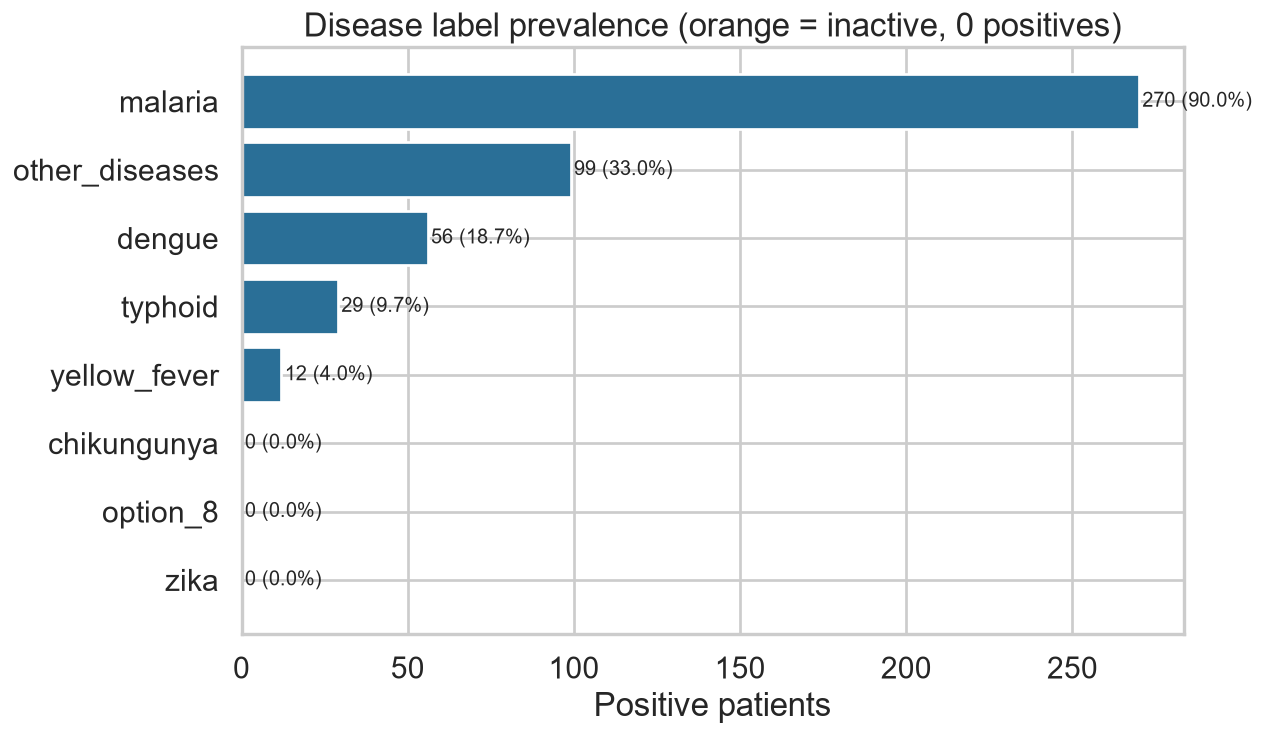

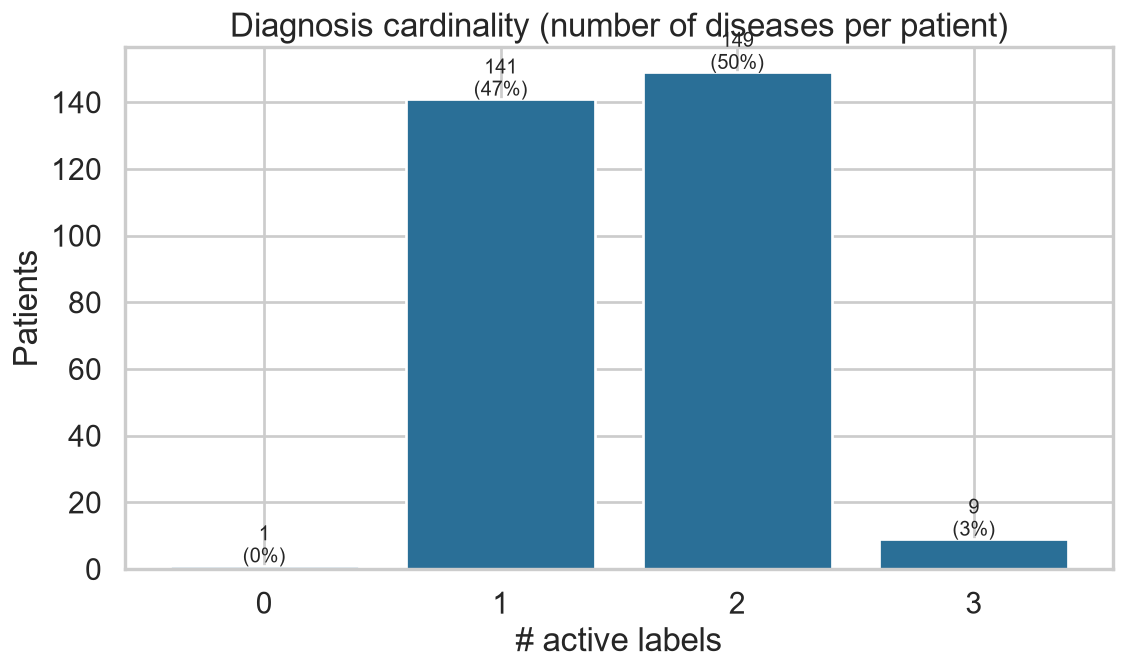

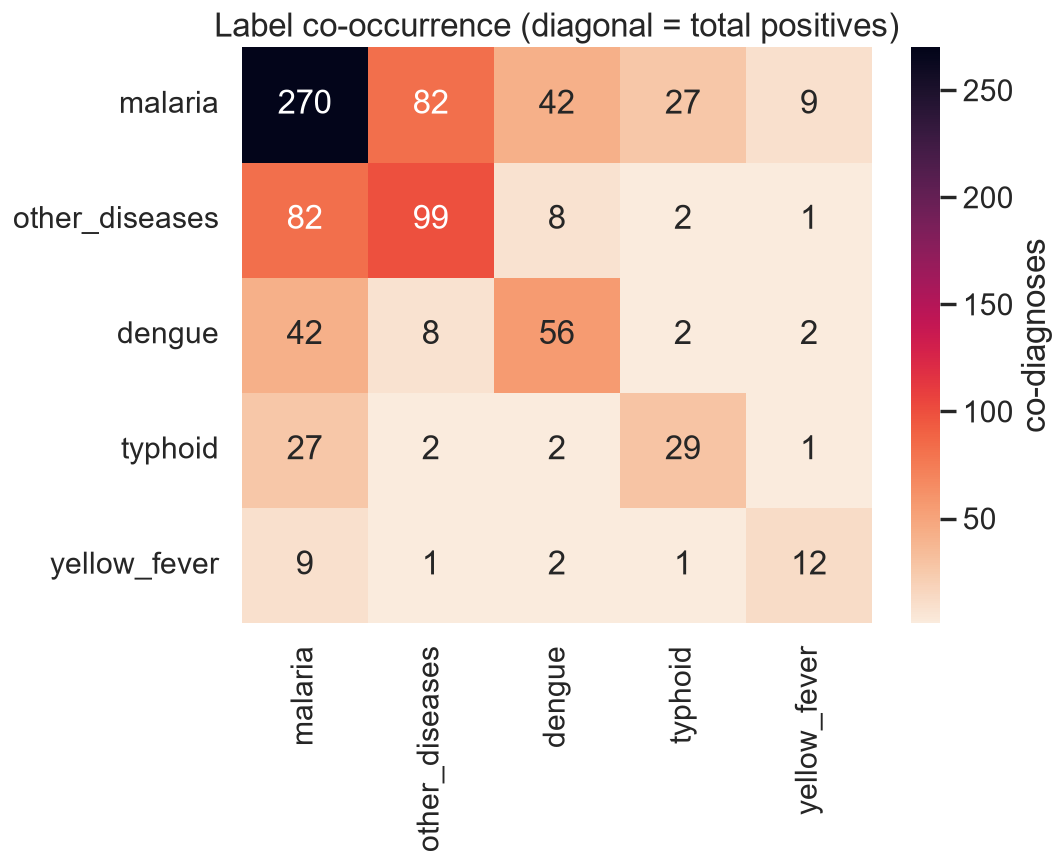

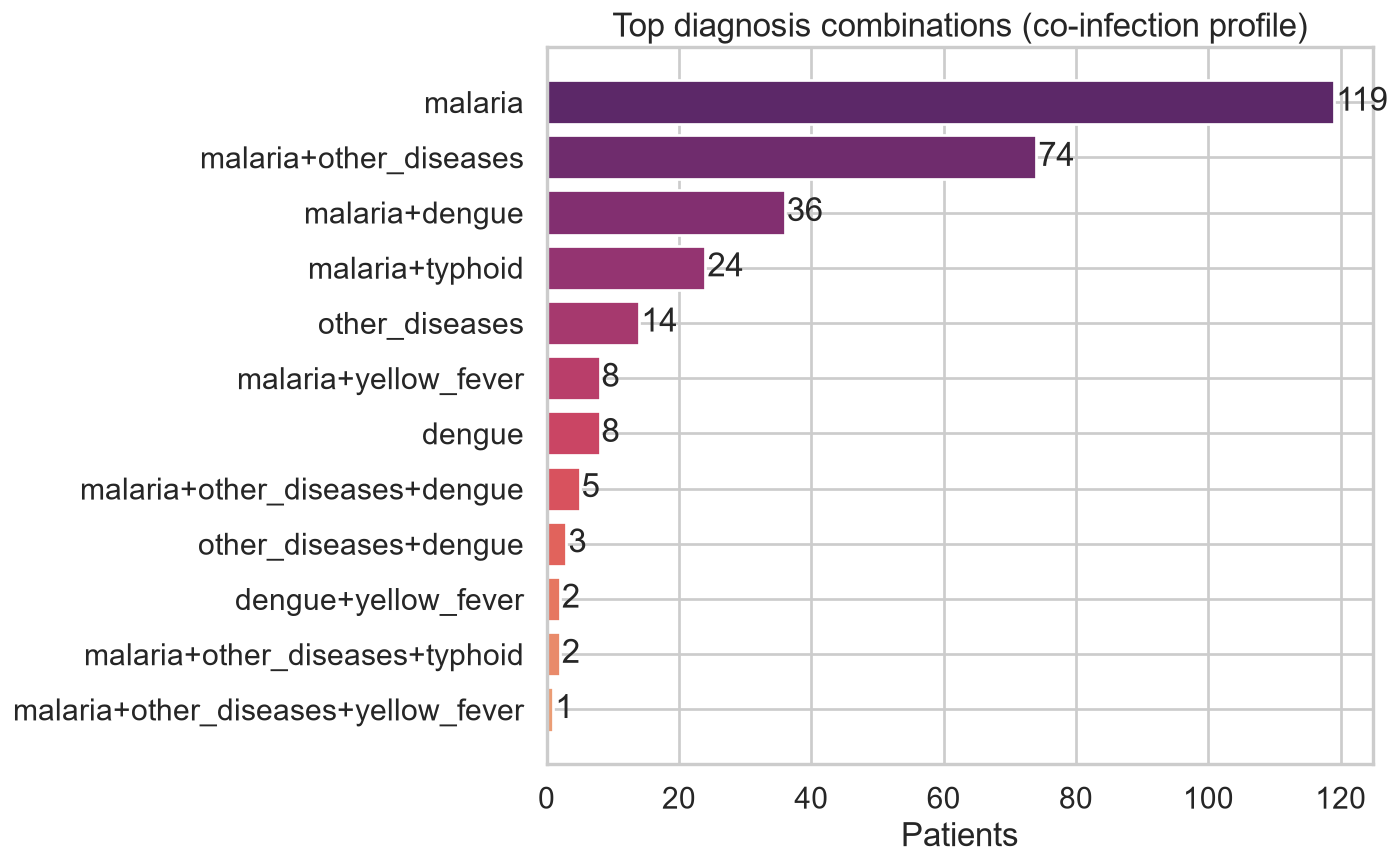

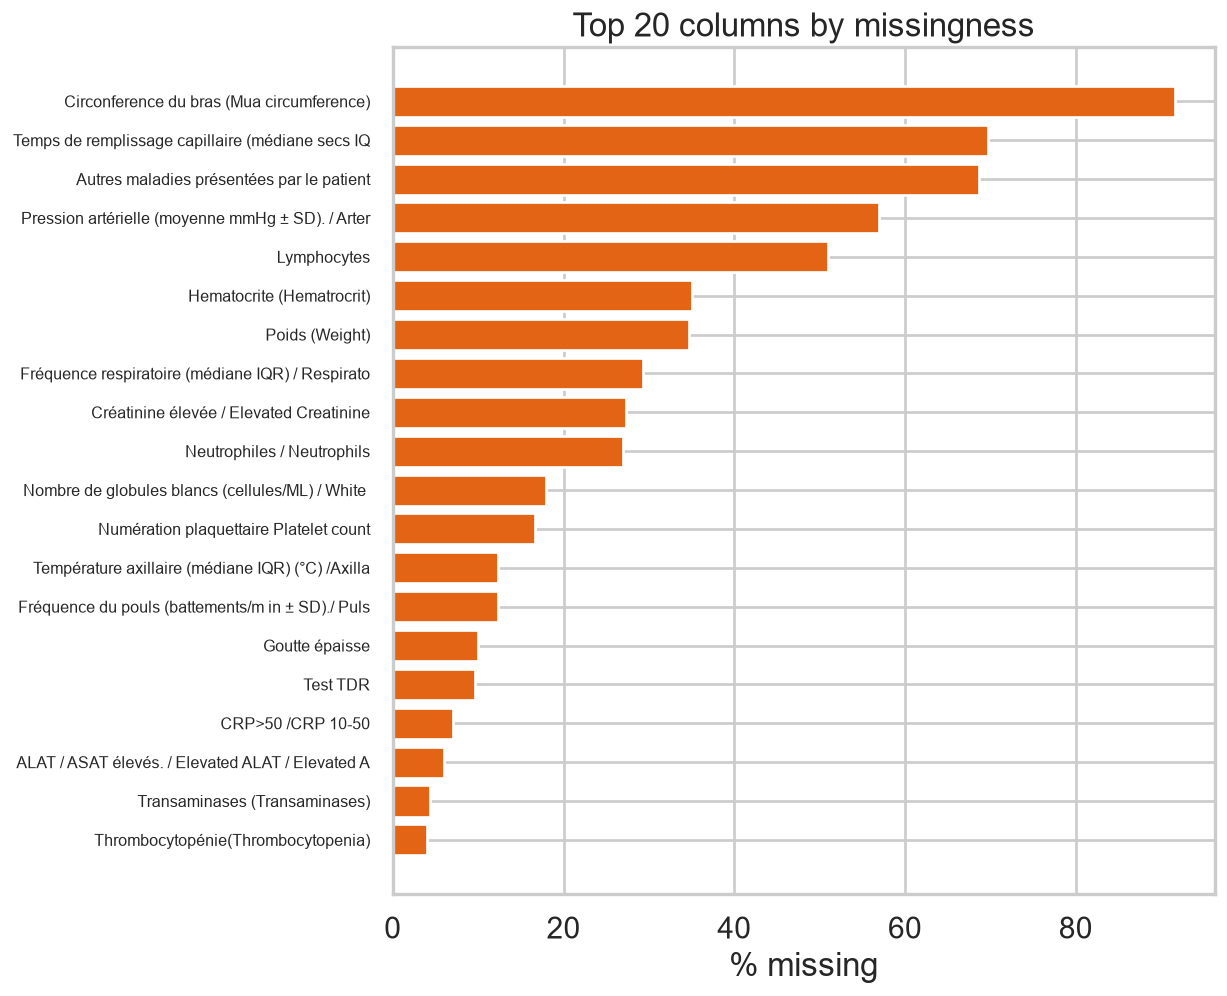

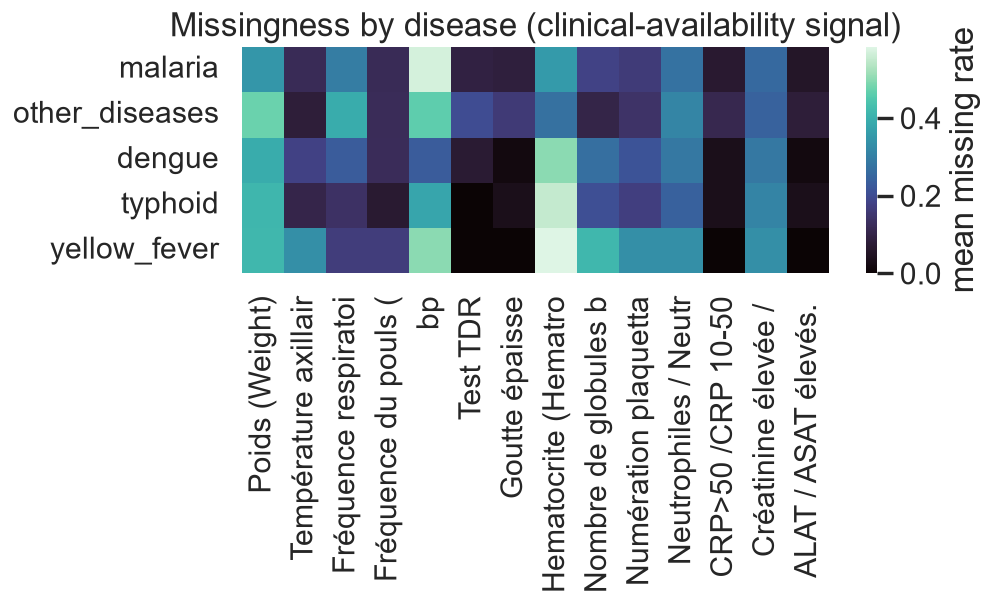

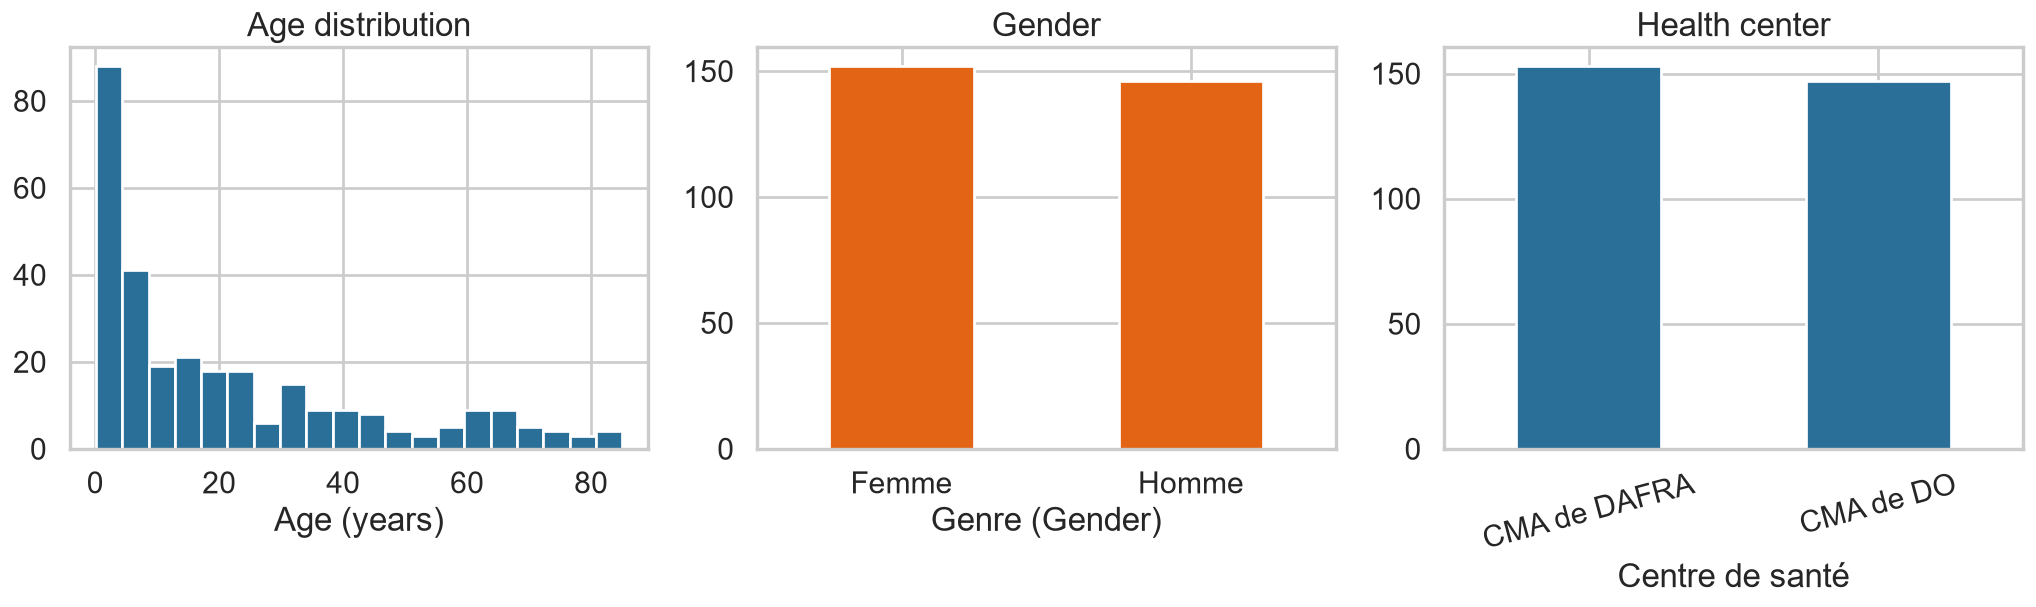

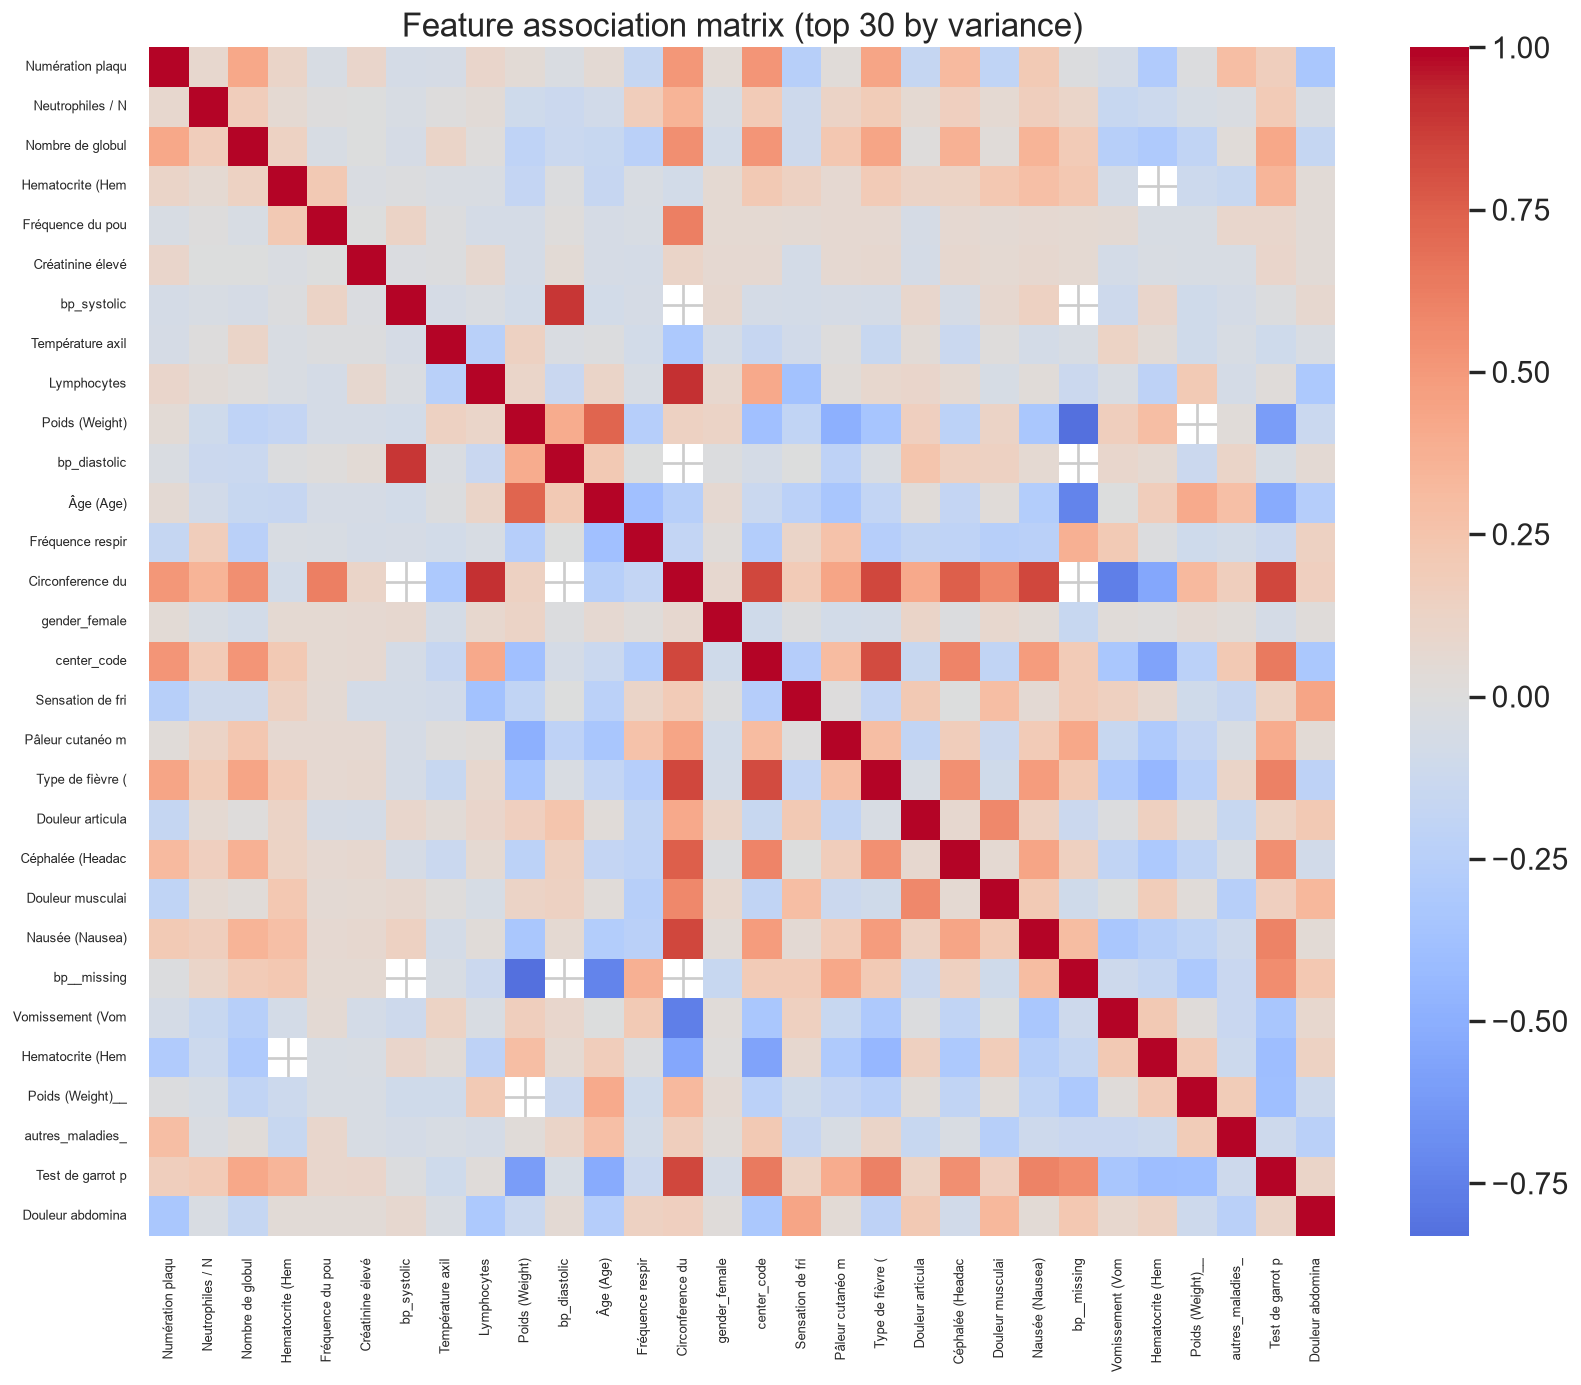

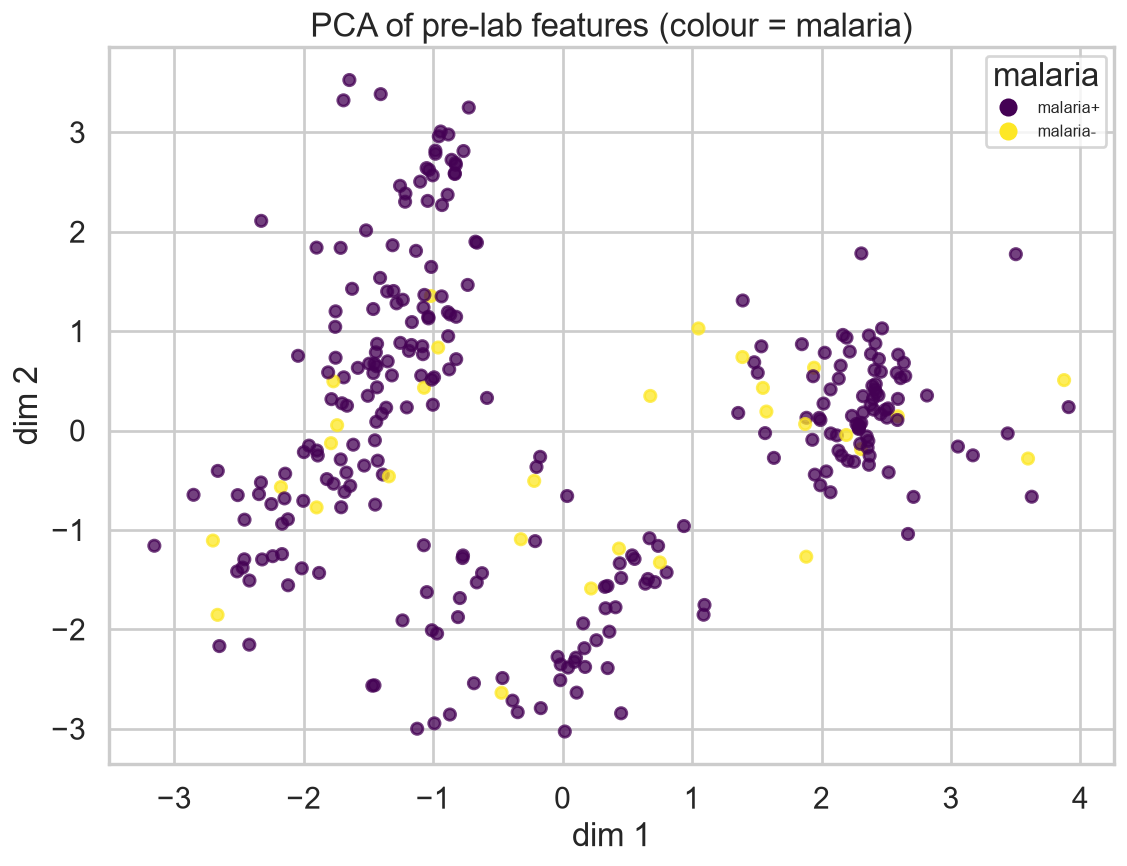

In [7]:
for f in ['target_distribution.png','label_cardinality.png','label_cooccurrence_heatmap.png',
          'coinfection_profile.png','missingness_top_features.png','missingness_by_disease.png',
          'demographics.png','association_matrix.png','feature_projection_pca.png']:
    pth = FIG / f
    if pth.exists(): display(Image(str(pth)))
    else: print('run run_pipeline.py to generate', f)

**Takeaways:** multi-label (not multi-class); malaria dominates (macro metrics needed); co-infection is central; lab/vital missingness is heavy and disease-dependent; *Dengue (Dengua)* / TDR / thick smear are leakage and are stage-gated out of the pre-lab model.